# 1. Data Loading

In [13]:
import sys
!{sys.executable} -m pip install imbalanced-learn optuna jinja2


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jinja2

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42


In [15]:
X_train = pd.read_csv("../Train_test_split/X_train.csv")
X_test  = pd.read_csv("../Train_test_split/X_test.csv")
y_train = pd.read_csv("../Train_test_split/y_train.csv").squeeze()
y_test  = pd.read_csv("../Train_test_split/y_test.csv").squeeze()


# 3. Imbalance analysis

In [16]:
class_labels = {0: 'Segment 0', 1: 'Segment 1', 2: 'Segment 2', 3: 'Segment 3'}

counts = y_train.value_counts().sort_index()
proportions = y_train.value_counts(normalize=True).sort_index() * 100

imbalance_df = pd.DataFrame({
    'Class': [class_labels[i] for i in counts.index],
    'Count': counts.values,
    'Percentage (%)': proportions.values.round(2)
})

ir = counts.max() / counts.min()

print('=' * 45)
print('         CLASS DISTRIBUTION — TRAIN SET')
print('=' * 45)
print(imbalance_df.to_string(index=False))
print(f'\nImbalance Ratio (IR): {ir:.2f}')
print(f'Majority class: Segment 2 ({counts.max():,} samples)')
print(f'Minority class: Segment 0 ({counts.min():,} samples)')
print()
if ir < 2:
    print('→ Mild imbalance (IR < 2). Mitigation may still improve minority recall.')
elif ir < 5:
    print('→ Moderate imbalance (IR 2–5). Mitigation recommended.')
else:
    print('→ Severe imbalance (IR > 5). Mitigation strongly recommended.')

         CLASS DISTRIBUTION — TRAIN SET
    Class  Count  Percentage (%)
Segment 0   4218           10.54
Segment 1   7331           18.33
Segment 2  17687           44.22
Segment 3  10764           26.91

Imbalance Ratio (IR): 4.19
Majority class: Segment 2 (17,687 samples)
Minority class: Segment 0 (4,218 samples)

→ Moderate imbalance (IR 2–5). Mitigation recommended.


# 3. Imbalance Mitigation

In [17]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Strategy': name,
        'Accuracy':   round(accuracy_score(y_te, y_pred), 4),
        'Precision':  round(precision_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Recall':     round(recall_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'F1 (macro)': round(f1_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'MCC':        round(matthews_corrcoef(y_te, y_pred), 4)
    }

# Estimador base: DecisionTreeClassifier con profundidad 1 (stump), típico de AdaBoost
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)

strategies = [
    ('No Resampling (Baseline)',
     AdaBoostClassifier(
         estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
         n_estimators=100, random_state=RANDOM_STATE
     )),

    ('RandomOverSampler',
     ImbPipeline([
         ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

    ('SMOTE',
     ImbPipeline([
         ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

    ('RandomUnderSampler',
     ImbPipeline([
         ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

    ('SMOTEENN',
     ImbPipeline([
         ('sampler', SMOTEENN(random_state=RANDOM_STATE)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

    ('SMOTETomek',
     ImbPipeline([
         ('sampler', SMOTETomek(random_state=RANDOM_STATE)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),
]

results = []
for name, pipeline in strategies:
    print(f'Training: {name}...', end=' ')
    res = evaluate_model(pipeline, X_train, y_train, X_test, y_test, name)
    results.append(res)
    print(f'F1={res["F1 (macro)"]:.4f} | MCC={res["MCC"]:.4f}')


# class_weight en el estimador base — AdaBoostClassifier no acepta class_weight directamente
print('Training: class_weight=balanced (via base estimator)...', end=' ')
ada_balanced = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced', random_state=RANDOM_STATE),
    n_estimators=100, random_state=RANDOM_STATE
)
ada_balanced.fit(X_train, y_train)
y_pred_bal = ada_balanced.predict(X_test)
res_bal = {
    'Strategy': 'class_weight=balanced',
    'Accuracy':   round(accuracy_score(y_test, y_pred_bal), 4),
    'Precision':  round(precision_score(y_test, y_pred_bal, average='macro', zero_division=0), 4),
    'Recall':     round(recall_score(y_test, y_pred_bal, average='macro', zero_division=0), 4),
    'F1 (macro)': round(f1_score(y_test, y_pred_bal, average='macro', zero_division=0), 4),
    'MCC':        round(matthews_corrcoef(y_test, y_pred_bal), 4)
}
results.append(res_bal)
print(f'F1={res_bal["F1 (macro)"]:.4f} | MCC={res_bal["MCC"]:.4f}')

results_df = pd.DataFrame(results)
print('\nDone!')

# A diferencia de GradientBoosting, AdaBoost puede beneficiarse más del rebalanceo porque
# su mecanismo de pesos de muestra (boosting weights) y los pesos de clase del estimador base
# pueden interactuar de forma complementaria. Con desbalanceo moderado, estrategias como SMOTE
# o class_weight=balanced suelen aportar mejoras más consistentes que en GBM.

Training: No Resampling (Baseline)... F1=0.6820 | MCC=0.5647
Training: RandomOverSampler... F1=0.6919 | MCC=0.5547
Training: SMOTE... F1=0.6958 | MCC=0.5593
Training: RandomUnderSampler... F1=0.6905 | MCC=0.5524
Training: SMOTEENN... F1=0.6361 | MCC=0.4970
Training: SMOTETomek... F1=0.6914 | MCC=0.5546
Training: class_weight=balanced (via base estimator)... F1=0.5529 | MCC=0.3783

Done!


In [18]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'MCC']
styled = results_df.style \
    .highlight_max(subset=metric_cols, color='black') \
    .set_caption('AdaBoost Performance by Imbalance Strategy (default hyperparameters)') \
    .format({c: '{:.4f}' for c in metric_cols})
styled

,Strategy,Accuracy,Precision,Recall,F1 (macro),MCC
0,No Resampling (Baseline),0.7037,0.7155,0.6708,0.6820,0.5647
1,RandomOverSampler,0.6854,0.6822,0.7071,0.6919,0.5547
2,SMOTE,0.6880,0.6876,0.7102,0.6958,0.5593
3,RandomUnderSampler,0.6837,0.6814,0.7057,0.6905,0.5524
4,SMOTEENN,0.6249,0.6360,0.6729,0.6361,0.4970
5,SMOTETomek,0.6854,0.6831,0.7051,0.6914,0.5546
6,class_weight=balanced,0.5279,0.5985,0.5742,0.5529,0.3783


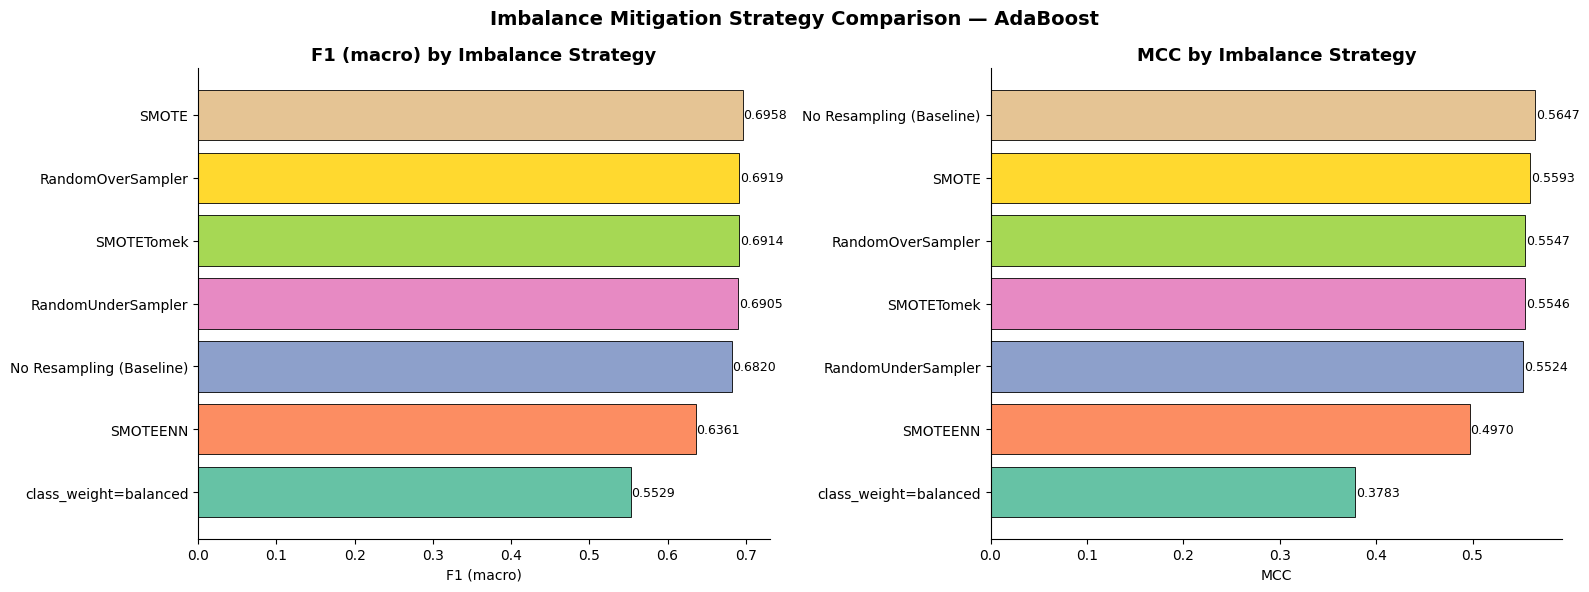

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_to_plot = ['F1 (macro)', 'MCC','Accuracy','Precision','Recall',]
palette = sns.color_palette('Set2', len(results_df))

for ax, metric in zip(axes, metrics_to_plot):
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Strategy'], sorted_df[metric], color=palette, edgecolor='black', linewidth=0.6)
    ax.set_title(f'{metric} by Imbalance Strategy', fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Imbalance Mitigation Strategy Comparison — AdaBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Hyperparameter Tuning with Optuna



In [20]:
from sklearn.model_selection import train_test_split

best_row = results_df.loc[results_df['F1 (macro)'].idxmax()]
best_strategy_name = best_row['Strategy']
print(f'Best imbalance strategy: "{best_strategy_name}" (F1={best_row["F1 (macro)"]:.4f})')
print('\nThis strategy will be used inside the Optuna objective function.')


Best imbalance strategy: "SMOTE" (F1=0.6958)

This strategy will be used inside the Optuna objective function.


In [21]:
def make_sampler(strategy_name, random_state=RANDOM_STATE):
    """Returns the imblearn sampler for the given strategy name."""
    mapping = {
        'RandomOverSampler': RandomOverSampler(random_state=random_state),
        'SMOTE':             SMOTE(random_state=random_state),
        'RandomUnderSampler':RandomUnderSampler(random_state=random_state),
        'SMOTEENN':          SMOTEENN(random_state=random_state),
        'SMOTETomek':        SMOTETomek(random_state=random_state),
    }
    return mapping.get(strategy_name, None)


def objective(trial):
    """Optuna objective: maximize macro F1 of AdaBoostClassifier."""
    # Espacio de hiperparámetros de AdaBoost
    n_estimators     = trial.suggest_int('n_estimators', 50, 500)
    learning_rate    = trial.suggest_float('learning_rate', 0.01, 2.0, log=True)
    max_depth        = trial.suggest_int('max_depth', 1, 5)          # profundidad del árbol base
    min_samples_split= trial.suggest_int('min_samples_split', 2, 20)  # del árbol base

    base_est = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=RANDOM_STATE
    )

    # Si la mejor estrategia usa class_weight, inyectarlo en el árbol base
    if best_strategy_name == 'class_weight=balanced':
        base_est = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            class_weight='balanced',
            random_state=RANDOM_STATE
        )

    clf = AdaBoostClassifier(
        estimator=base_est,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=RANDOM_STATE
    )

    # Wrap en pipeline de resampling si aplica
    sampler = make_sampler(best_strategy_name)
    if sampler is not None:
        model = ImbPipeline([('sampler', sampler), ('clf', clf)])
    else:
        model = clf

    # Train/Val split 80/20 estratificado
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
    )

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

    trial.report(f1, 0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return f1


print('Objective function defined using AdaBoostClassifier.')


Objective function defined using AdaBoostClassifier.


In [22]:
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)

print('Starting Optuna optimization (30 trials)...')
print('Pruner: MedianPruner — unpromising trials will be cut early.\n')

study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nOptimization complete!')
print(f'Best trial:  #{study.best_trial.number}')
print(f'Best CV F1:  {study.best_value:.4f}')
print(f'Best params: {study.best_params}')


Starting Optuna optimization (30 trials)...
Pruner: MedianPruner — unpromising trials will be cut early.



Best trial: 13. Best value: 0.765477: 100%|██████████| 30/30 [1:06:50<00:00, 133.69s/it]


Optimization complete!
Best trial:  #13
Best CV F1:  0.7655
Best params: {'n_estimators': 416, 'learning_rate': 0.07746498983319838, 'max_depth': 5, 'min_samples_split': 2}


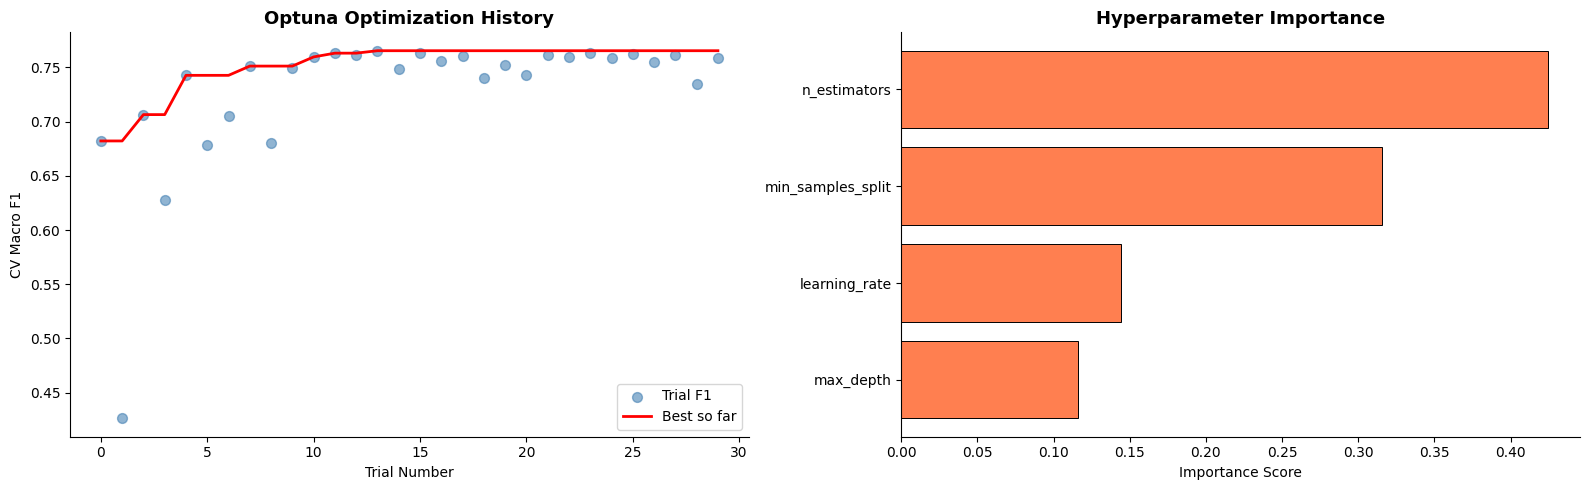


Completed trials: 30 | Pruned trials: 0
Pruning rate: 0.0% — MedianPruner saved computation time.


In [23]:
# --- Plot optimization history ---
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Optimization history
trial_nums = [t.number for t in completed]
trial_vals = [t.value for t in completed]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

axes[0].scatter(trial_nums, trial_vals, alpha=0.6, color='steelblue', s=50, label='Trial F1')
axes[0].plot(trial_nums, best_so_far, color='red', linewidth=2, label='Best so far')
pruned_nums = [t.number for t in pruned]
if pruned_nums:
    axes[0].axvline(x=pruned_nums[0], color='grey', linestyle='--', alpha=0.4, label='Pruned trials')
    for pn in pruned_nums[1:]:
        axes[0].axvline(x=pn, color='grey', linestyle='--', alpha=0.4)
axes[0].set_title('Optuna Optimization History', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('CV Macro F1')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Parameter importance (top 6)
importances = optuna.importance.get_param_importances(study)
imp_df = pd.DataFrame(list(importances.items()), columns=['Parameter', 'Importance']).head(6)
imp_df = imp_df.sort_values('Importance')
axes[1].barh(imp_df['Parameter'], imp_df['Importance'], color='coral', edgecolor='black', linewidth=0.7)
axes[1].set_title('Hyperparameter Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'\nCompleted trials: {len(completed)} | Pruned trials: {len(pruned)}')
print(f'Pruning rate: {len(pruned)/len(study.trials)*100:.1f}% — MedianPruner saved computation time.')


# 6. AdaBoost with Best Parameters

In [24]:
best_params = study.best_params.copy()

# Reconstruir el estimador base con los mejores hiperparámetros
base_estimator_params = {
    'max_depth': best_params.pop('max_depth'),
    'min_samples_split': best_params.pop('min_samples_split'),
    'random_state': RANDOM_STATE
}
if best_strategy_name == 'class_weight=balanced':
    base_estimator_params['class_weight'] = 'balanced'

best_base_est = DecisionTreeClassifier(**base_estimator_params)

final_clf = AdaBoostClassifier(
    estimator=best_base_est,
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    random_state=RANDOM_STATE
)

sampler = make_sampler(best_strategy_name)
if sampler is not None:
    final_model = ImbPipeline([('sampler', sampler), ('clf', final_clf)])
    final_model.fit(X_train, y_train)
else:
    final_model = final_clf
    final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

print('Final model trained on full training set (AdaBoost).')
print(f'Strategy: {best_strategy_name}')
print(f'Best params: {study.best_params}')


Final model trained on full training set (AdaBoost).
Strategy: SMOTE
Best params: {'n_estimators': 416, 'learning_rate': 0.07746498983319838, 'max_depth': 5, 'min_samples_split': 2}


In [25]:
print('=' * 55)
print('   FINAL MODEL — TEST SET RESULTS')
print('=' * 55)

acc  = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, average='macro', zero_division=0)
rec  = recall_score(y_test, y_pred_final, average='macro', zero_division=0)
f1   = f1_score(y_test, y_pred_final, average='macro', zero_division=0)
mcc  = matthews_corrcoef(y_test, y_pred_final)

metrics_final = pd.DataFrame([{
    'Accuracy': round(acc, 4),
    'Precision (macro)': round(prec, 4),
    'Recall (macro)': round(rec, 4),
    'F1 (macro)': round(f1, 4),
    'MCC': round(mcc, 4)
}])

print(metrics_final.to_string(index=False))

print('\n--- Per-Class Report ---')
print(classification_report(y_test, y_pred_final,
                             target_names=[class_labels[i] for i in range(4)]))


   FINAL MODEL — TEST SET RESULTS
 Accuracy  Precision (macro)  Recall (macro)  F1 (macro)    MCC
   0.7415             0.7591          0.7596      0.7571 0.6292

--- Per-Class Report ---
              precision    recall  f1-score   support

   Segment 0       0.80      0.84      0.82      1055
   Segment 1       0.85      0.77      0.81      1832
   Segment 2       0.81      0.74      0.77      4422
   Segment 3       0.58      0.69      0.63      2691

    accuracy                           0.74     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.75      0.74      0.75     10000



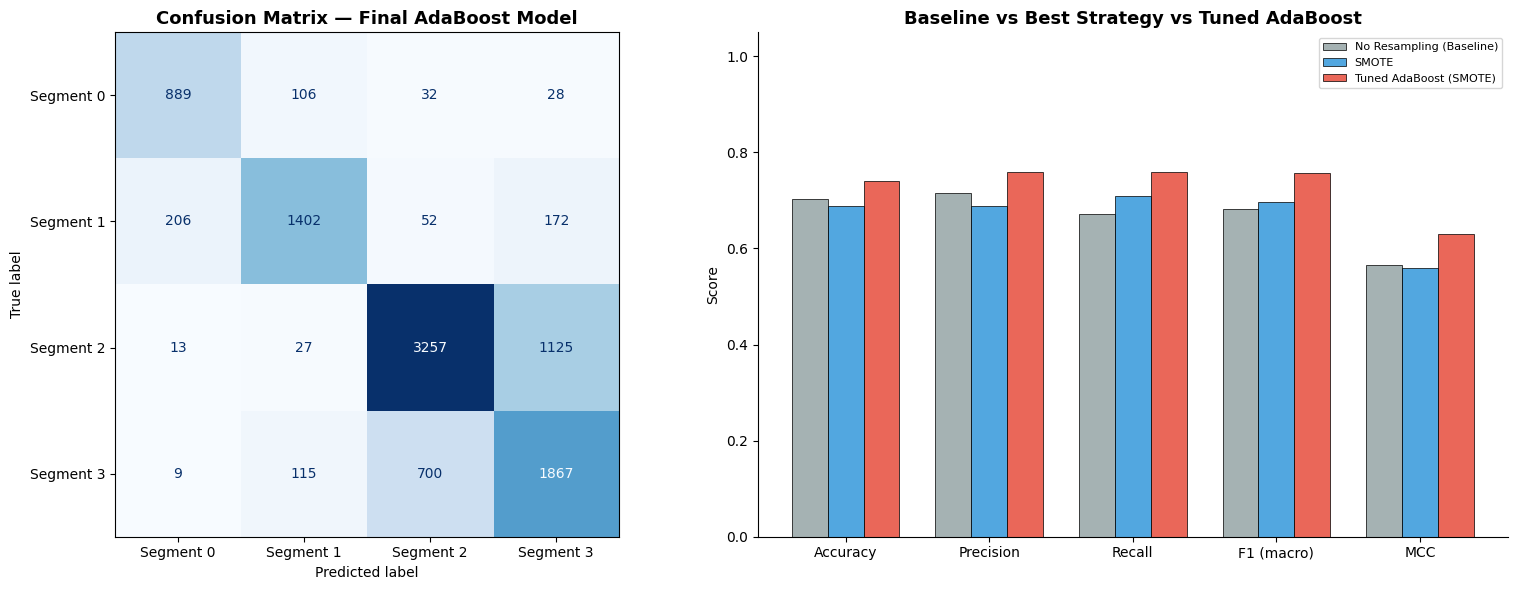

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=[class_labels[i] for i in range(4)],
    colorbar=False,
    ax=axes[0],
    cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Final AdaBoost Model', fontsize=13, fontweight='bold')

# Compare baseline vs tuned
compare_df = results_df[results_df['Strategy'].isin(['No Resampling (Baseline)', best_strategy_name])].copy()
tuned_row = pd.DataFrame([{
    'Strategy': f'Tuned AdaBoost ({best_strategy_name})',
    'Accuracy': round(acc, 4),
    'Precision': round(prec, 4),
    'Recall': round(rec, 4),
    'F1 (macro)': round(f1, 4),
    'MCC': round(mcc, 4)
}])
compare_df = pd.concat([compare_df, tuned_row], ignore_index=True)

metrics_to_bar = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'MCC']
x = np.arange(len(metrics_to_bar))
width = 0.25
bar_colors = ['#95a5a6', '#3498db', '#e74c3c']

for i, (_, row) in enumerate(compare_df.iterrows()):
    vals = [row[m] for m in metrics_to_bar]
    bars = axes[1].bar(x + i*width, vals, width, label=row['Strategy'], color=bar_colors[i], alpha=0.85, edgecolor='black', linewidth=0.6)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics_to_bar)
axes[1].set_title('Baseline vs Best Strategy vs Tuned AdaBoost', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
